# Subthreshold benchmark analysis — gradient descent vs. Nelder-Mead

Headline question: in the non-spiking regime, does MSE gradient descent (`grad`)
match or beat Nelder-Mead (`nm`) on (1) convergence speed and (2) fit quality?
Paired across `scenario_idx` (both optimizers fit the same ground truth from the
same fixed init).

**Caveat on the iteration axis:** one grad "iter" is a forward+backward pass (one
Adam step), one NM "iter" is a single forward loss evaluation. They are roughly
comparable as loss-evaluations but grad's is more expensive per step, so
`elapsed_s` is the fair cost metric.

Reads `results_subthreshold.csv` + `results_subthreshold_curves.csv`. Figures are
plotted inline **and** still saved to `figures/` (same as the original script):
`subthreshold_loss_curves.pdf`, `subthreshold_convergence.pdf`,
`subthreshold_fit_quality.pdf`.

In [1]:
import csv
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import binomtest, wilcoxon

# Resolve the 5_code dir whether the notebook runs from 5_code/ or 5_code/notebooks/.
ROOT = Path.cwd()
if not (ROOT / "results_subthreshold.csv").exists():
    ROOT = ROOT.parent
FIGS = ROOT / "figures"
FIGS.mkdir(exist_ok=True)

METHOD = "grad"          # method under test
BASELINE = "nm"
PARAMS = ["C_m", "E_L", "g_L"]

# --- Plot style (matches the thesis figure defaults) ------------------------
mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["DejaVu Serif", "Times New Roman", "Times"],
    "mathtext.fontset": "cm",
    "axes.labelsize": 10, "axes.titlesize": 10, "axes.titleweight": "regular",
    "axes.linewidth": 0.6, "xtick.labelsize": 9, "ytick.labelsize": 9,
    "legend.fontsize": 8.5, "legend.frameon": False,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.linewidth": 0.4, "grid.alpha": 0.35,
    "pdf.fonttype": 42, "ps.fonttype": 42, "savefig.dpi": 300,
    "savefig.bbox": "tight", "savefig.pad_inches": 0.02,
})
COLORS = {"grad": "#0072B2", "nm": "#E69F00"}
LABELS = {"grad": r"$\nabla$ (Adam)", "nm": "Nelder-Mead"}
MARKERS = {"grad": "o", "nm": "^"}

In [2]:
def _f(v):
    try:
        return float(v)
    except (TypeError, ValueError):
        return float("nan")


rows = list(csv.DictReader(open(ROOT / "results_subthreshold.csv")))
BASES = sorted({r["base"] for r in rows})
DELTAS = sorted({_f(r["delta"]) for r in rows})

# index[(scenario_idx, method)] -> row
index = {(int(r["scenario_idx"]), r["method"]): r for r in rows}
SCENARIO_IDS = sorted({int(r["scenario_idx"]) for r in rows})


def mean_param_err(row):
    return float(np.mean([_f(row[f"param_err_{p}"]) for p in PARAMS]))


def get_metric(row, metric):
    return mean_param_err(row) if metric == "param_err" else _f(row[metric])


def paired(metric, base=None):
    """(grad, nm) arrays paired on scenario_idx. Drops missing/NaN/errored pairs."""
    a_vals, b_vals = [], []
    for sid in SCENARIO_IDS:
        ra, rb = index.get((sid, METHOD)), index.get((sid, BASELINE))
        if ra is None or rb is None:
            continue
        if base is not None and ra["base"] != base:
            continue
        if int(_f(ra["converged"])) < 0 or int(_f(rb["converged"])) < 0:
            continue  # errored run
        va, vb = get_metric(ra, metric), get_metric(rb, metric)
        if not (np.isfinite(va) and np.isfinite(vb)):
            continue
        a_vals.append(va)
        b_vals.append(vb)
    return np.array(a_vals), np.array(b_vals)


def wilcoxon_report(a, b):
    """Paired signed-rank, H1 = grad < nm (lower = better). Returns (p, win%, med d)."""
    if len(a) < 6 or np.allclose(a, b):
        return float("nan"), float("nan"), float("nan")
    try:
        _, p = wilcoxon(a, b, alternative="less")
    except ValueError:
        p = float("nan")
    win = float(np.mean(a < b) + 0.5 * np.mean(a == b))
    return p, win, float(np.median(a - b))


def mcnemar_converged(base=None):
    a, b = paired("converged", base)
    n10 = int(np.sum((a == 1) & (b == 0)))   # grad converges, nm doesn't
    n01 = int(np.sum((a == 0) & (b == 1)))   # nm converges, grad doesn't
    n = n10 + n01
    p = binomtest(min(n10, n01), n, 0.5).pvalue if n > 0 else float("nan")
    return n10, n01, p

## Paired statistical tests

`grad` vs `nm`, paired on `scenario_idx` (lower = better; H1 = grad < nm). Wilcoxon
signed-rank on each metric, McNemar on the binary `converged` outcome, plus LaTeX
rows for the results table.

In [3]:
print("=" * 82)
print(f"PAIRED TESTS: {METHOD} vs {BASELINE}   (lower = better; H1 = grad < nm)")
print("=" * 82)
METRICS = [("final_loss", "final MSE"), ("param_err", "mean |dparam|/range"),
           ("iters_to_tol", "iters-to-tol"), ("elapsed_s", "wall-clock s")]
for base in BASES + ["POOLED"]:
    print(f"\n-- {base} --")
    print(f"{'metric':<22}{'n':>4}{'med d(grad-nm)':>16}{'grad win%':>11}{'p(Wilcox)':>11}")
    for metric, label in METRICS:
        a, b = (paired(metric) if base == "POOLED" else paired(metric, base))
        p, win, med = wilcoxon_report(a, b)
        print(f"{label:<22}{len(a):>4}{med:>16.4g}{100*win:>10.0f}%{p:>11.4f}")
    n10, n01, pmc = (mcnemar_converged() if base == "POOLED"
                     else mcnemar_converged(base))
    print(f"{'converged (McNemar)':<22}{'':>4}grad/nm-only = {n10}/{n01}, p={pmc:.4f}")

print("\n=== LaTeX rows (grad vs nm, per base; paste into results table) ===")
for base in BASES:
    a, b = paired("final_loss", base)
    p, win, med = wilcoxon_report(a, b)
    sname = base.replace("_", " ")
    print(rf"{sname} & ${med:+.4g}$ & ${100*win:.0f}\%$ & ${p:.3f}$ \\")

PAIRED TESTS: grad vs nm   (lower = better; H1 = grad < nm)

-- tonic --
metric                   n  med d(grad-nm)  grad win%  p(Wilcox)
final MSE              200         -0.0535        77%     0.0000
mean |dparam|/range    200         0.02444        24%     1.0000
iters-to-tol           200            -0.5        56%     0.1810
wall-clock s           200          0.2035         0%     1.0000
converged (McNemar)       grad/nm-only = 71/18, p=0.0000

-- POOLED --
metric                   n  med d(grad-nm)  grad win%  p(Wilcox)
final MSE              200         -0.0535        77%     0.0000
mean |dparam|/range    200         0.02444        24%     1.0000
iters-to-tol           200            -0.5        56%     0.1810
wall-clock s           200          0.2035         0%     1.0000
converged (McNemar)       grad/nm-only = 71/18, p=0.0000

=== LaTeX rows (grad vs nm, per base; paste into results table) ===
tonic & $-0.0535$ & $77\%$ & $0.000$ \\


## Figure 1 — loss vs iteration (median ± IQR)

Per-run loss curves, aggregated to the median trajectory with an inter-quartile
band, one panel per base. Each run is padded to the common length with its final
value so a run that stops early continues at its converged loss.

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


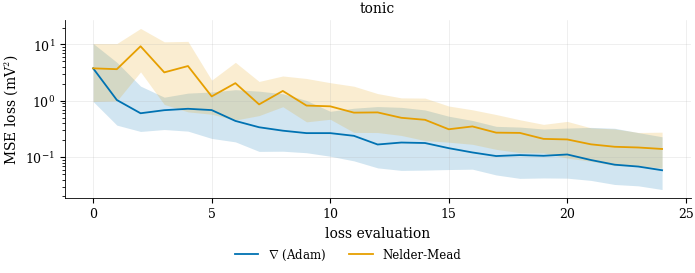

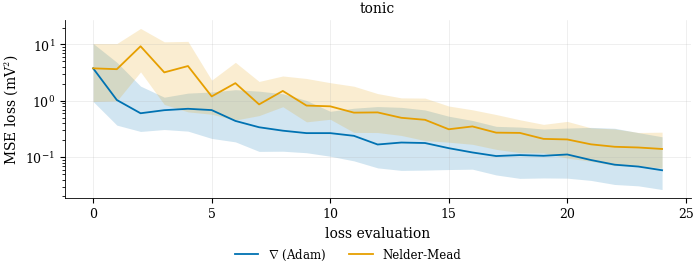

In [4]:
curve_rows = list(csv.DictReader(open(ROOT / "results_subthreshold_curves.csv")))
# curves[(base, method)] -> list of per-run loss arrays
curves: dict = {}
by_run: dict = {}
for r in curve_rows:
    key = (int(r["scenario_idx"]), r["base"], r["method"])
    by_run.setdefault(key, []).append((int(r["iter"]), _f(r["loss"])))
for (sid, base, method), pts in by_run.items():
    pts.sort()
    curves.setdefault((base, method), []).append(np.array([p[1] for p in pts]))


def median_iqr(curve_list):
    """Pad each curve to common length with its last value, then median + IQR."""
    if not curve_list:
        return None
    max_len = max(len(c) for c in curve_list)
    mat = np.array([np.concatenate([c, np.full(max_len - len(c), c[-1])])
                    for c in curve_list])
    return (np.median(mat, axis=0),
            np.percentile(mat, 25, axis=0), np.percentile(mat, 75, axis=0))


fig, axes = plt.subplots(1, len(BASES), figsize=(7.0, 2.8), sharey=True,
                         constrained_layout=True, squeeze=False)
for ax, base in zip(axes[0], BASES):
    for m in ("grad", "nm"):
        res = median_iqr(curves.get((base, m), []))
        if res is None:
            continue
        med, lo, hi = res
        x = np.arange(len(med))
        ax.plot(x, med, color=COLORS[m], linewidth=1.3, label=LABELS[m])
        ax.fill_between(x, lo, hi, color=COLORS[m], alpha=0.18, linewidth=0)
    ax.set_yscale("log")
    ax.set_xlabel("loss evaluation")
    ax.set_title(base.replace("_", " "))
axes[0][0].set_ylabel("MSE loss (mV$^2$)")
h, l = axes[0][0].get_legend_handles_labels()
fig.legend(h, l, loc="outside lower center", ncol=2)
fig.savefig(FIGS / "subthreshold_loss_curves.pdf")
fig;

## Figure 2 — convergence

P(converged) vs perturbation scale (pooled across bases), and, for the runs that
did converge, the distribution of iterations-to-tolerance and wall-clock time.

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


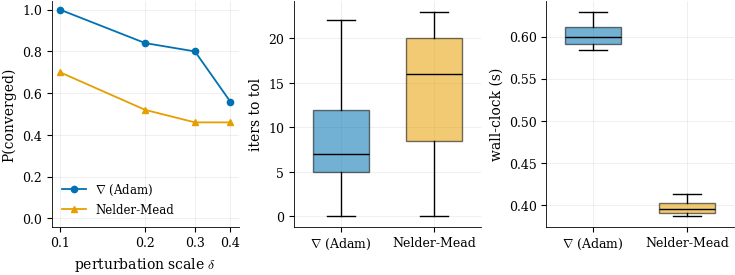

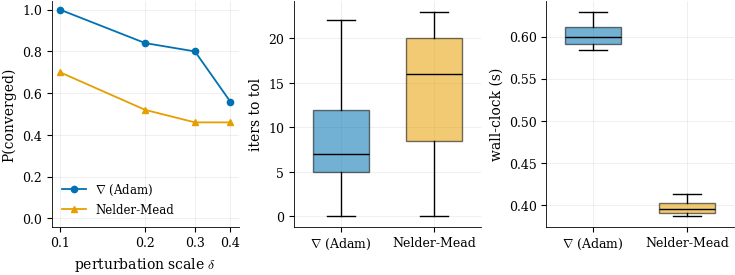

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(7.4, 2.8), constrained_layout=True)
# (a) P(converged) vs delta (pooled across bases, per method)
ax = axes[0]
for m in ("grad", "nm"):
    ys = []
    for d in DELTAS:
        vals = [int(_f(index[k]["converged"])) for k in index
                if k[1] == m and _f(index[k]["delta"]) == d]
        vals = [v for v in vals if v in (0, 1)]
        ys.append(sum(vals) / len(vals) if vals else float("nan"))
    ax.plot(DELTAS, ys, color=COLORS[m], marker=MARKERS[m], markersize=4.5,
            linewidth=1.3, label=LABELS[m])
ax.set_xscale("log"); ax.set_xticks(DELTAS)
ax.set_xticklabels([f"{d:g}" for d in DELTAS])
ax.tick_params(axis="x", which="minor", length=0)
ax.set_xlabel(r"perturbation scale $\delta$"); ax.set_ylabel("P(converged)")
ax.set_ylim(-0.04, 1.04); ax.legend()
# (b) iters-to-tol and (c) elapsed_s boxplots (converged runs only)
for ax, metric, ylab in [(axes[1], "iters_to_tol", "iters to tol"),
                         (axes[2], "elapsed_s", "wall-clock (s)")]:
    data = []
    for m in ("grad", "nm"):
        vals = [_f(index[k][metric]) for k in index if k[1] == m
                and int(_f(index[k]["converged"])) == 1 and _f(index[k][metric]) >= 0]
        data.append([v for v in vals if np.isfinite(v)])
    bp = ax.boxplot(data, tick_labels=[LABELS["grad"], LABELS["nm"]],
                    showfliers=False, patch_artist=True, widths=0.6)
    for patch, m in zip(bp["boxes"], ("grad", "nm")):
        patch.set_facecolor(COLORS[m]); patch.set_alpha(0.55)
    for med in bp["medians"]:
        med.set_color("black")
    ax.set_ylabel(ylab)
fig.savefig(FIGS / "subthreshold_convergence.pdf")
fig;

## Figure 3 — fit quality

Final-MSE (clean re-simulation, log scale) and mean normalized parameter-recovery
error, per method.

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


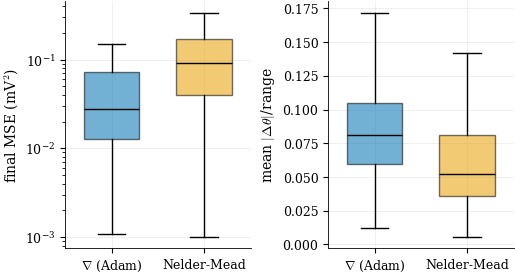

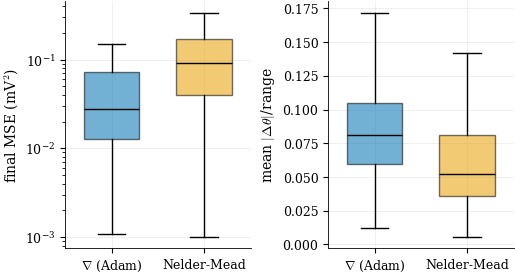

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(5.2, 2.8), constrained_layout=True)
for ax, metric, ylab, logy in [(axes[0], "final_loss", "final MSE (mV$^2$)", True),
                               (axes[1], "param_err", r"mean $|\Delta\theta|$/range", False)]:
    data = []
    for m in ("grad", "nm"):
        vals = [get_metric(index[k], metric) for k in index if k[1] == m
                and int(_f(index[k]["converged"])) >= 0]
        data.append([v for v in vals if np.isfinite(v)])
    bp = ax.boxplot(data, tick_labels=[LABELS["grad"], LABELS["nm"]],
                    showfliers=False, patch_artist=True, widths=0.6)
    for patch, m in zip(bp["boxes"], ("grad", "nm")):
        patch.set_facecolor(COLORS[m]); patch.set_alpha(0.55)
    for med in bp["medians"]:
        med.set_color("black")
    if logy:
        ax.set_yscale("log")
    ax.set_ylabel(ylab)
fig.savefig(FIGS / "subthreshold_fit_quality.pdf")

fig;


## Figure 4 — example loss trajectories

A few raw, individual loss curves (not aggregated) for both optimizers, so the
step-by-step descent shape is visible. For each base the easiest (smallest
$\delta$) and hardest (largest $\delta$) scenario are shown, with gradient descent
and Nelder-Mead overlaid. Saved to `figures/subthreshold_example_trajectories.pdf`.

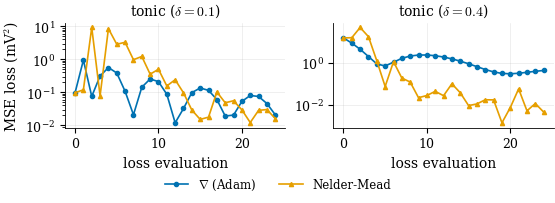

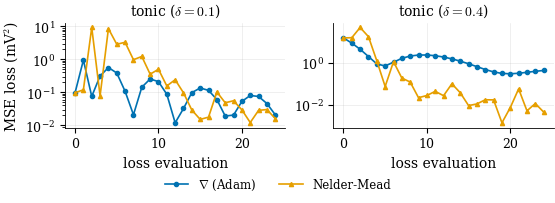

In [9]:
# A few individual loss trajectories (not aggregated): for each base, the
# lowest- and highest-delta scenario, with grad and nm overlaid on the same axes.
def _run_curve(sid, method):
    base = index[(sid, method)]["base"]
    pts = sorted(by_run[(sid, base, method)])
    return np.array([p[1] for p in pts])


examples = []  # (sid, base, delta), 2 per base spanning the perturbation range
for base in BASES:
    sids = [s for s in SCENARIO_IDS if index[(s, "grad")]["base"] == base]
    lo = min(sids, key=lambda s: _f(index[(s, "grad")]["delta"]))
    hi = max(sids, key=lambda s: _f(index[(s, "grad")]["delta"]))
    examples += [(lo, base, _f(index[(lo, "grad")]["delta"])),
                 (hi, base, _f(index[(hi, "grad")]["delta"]))]

fig, axes = plt.subplots(len(BASES), 2, figsize=(5.6, 2.1 * len(BASES)),
                         constrained_layout=True, squeeze=False)
for ax, (sid, base, delta) in zip(axes.ravel(), examples):
    for m in ("grad", "nm"):
        y = _run_curve(sid, m)
        ax.plot(np.arange(len(y)), y, color=COLORS[m], marker=MARKERS[m],
                markersize=3, linewidth=1.2, label=LABELS[m])
    ax.set_yscale("log")
    ax.set_title(rf"{base.replace('_', ' ')} ($\delta={delta:g}$)")
for ax in axes[-1]:
    ax.set_xlabel("loss evaluation")
for ax in axes[:, 0]:
    ax.set_ylabel("MSE loss (mV$^2$)")
h, l = axes[0, 0].get_legend_handles_labels()
fig.legend(h, l, loc="outside lower center", ncol=2)
fig.savefig(FIGS / "subthreshold_example_trajectories.pdf")
fig;

## Figure 5 — fitted voltage traces (example scenarios)

For the same example scenarios as the loss trajectories, the simulated voltage
trace **after fitting** (dashed) overlaid on the ground-truth target (black). Each
optimizer's recovered `C_m, E_L, g_L` (from the summary CSV) are plugged back into
a clean, non-surrogate simulation. Saved to `figures/subthreshold_example_fits.pdf`.

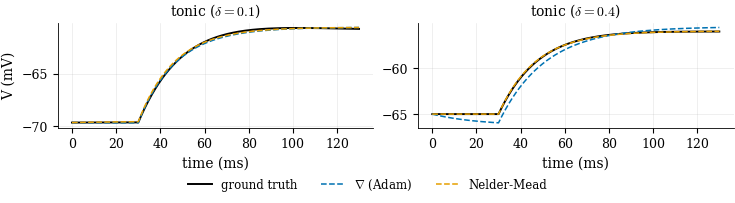

In [10]:
# Simulated voltage traces after fitting, for the same example scenarios as the
# loss trajectories above. We re-simulate INIT + the fitted (C_m, E_L, g_L) — read
# from the summary CSV — and overlay on the ground-truth target trace. The seeded
# scenario traces are regenerated via the benchmark module (the CSV stores only the
# three fitted params, not the full GT trace), so this re-runs the GT sims once.
import benchmark_subthreshold as B

scenarios_by_id = {sc["scenario_idx"]: sc for sc in B.generate_scenarios()}

# Same examples as the trajectory figure: easiest/hardest scenario per base.
examples = []
for base in BASES:
    sids = [s for s in SCENARIO_IDS if index[(s, "grad")]["base"] == base]
    lo = min(sids, key=lambda s: _f(index[(s, "grad")]["delta"]))
    hi = max(sids, key=lambda s: _f(index[(s, "grad")]["delta"]))
    examples += [(lo, base, _f(index[(lo, "grad")]["delta"])),
                 (hi, base, _f(index[(hi, "grad")]["delta"]))]

fig, axes = plt.subplots(len(BASES), 2, figsize=(7.4, 2.1 * len(BASES)),
                         constrained_layout=True, squeeze=False)
for ax, (sid, base, delta) in zip(axes.ravel(), examples):
    sc = scenarios_by_id[sid]
    assert sc["base"] == base, "scenario regeneration is out of sync with the CSV"
    trace = sc["trace"]
    ax.plot(trace.time, trace.voltage, color="black", linewidth=1.4,
            label="ground truth")
    for m in ("grad", "nm"):
        fitted = {p: _f(index[(sid, m)][f"{p}_fit"]) for p in B.TRAINABLE}
        params = {**B.INIT, **fitted}
        with B._silence():
            sim = B.simulate_with_current_trace(
                params=params, current_trace_pA=trace.current, dt_ms=B.DT_MS,
                use_surrogate=False, v_init=float(trace.voltage[0]))
        v = np.asarray(sim.voltage)[:len(trace.time)]
        ax.plot(trace.time[:len(v)], v, color=COLORS[m], linewidth=1.1,
                linestyle="--", label=LABELS[m])
    ax.set_title(rf"{base.replace('_', ' ')} ($\delta={delta:g}$)")
for ax in axes[-1]:
    ax.set_xlabel("time (ms)")
for ax in axes[:, 0]:
    ax.set_ylabel("V (mV)")
h, l = axes[0, 0].get_legend_handles_labels()
fig.legend(h, l, loc="outside lower center", ncol=3)
fig.savefig(FIGS / "subthreshold_example_fits.pdf")

fig;